In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [ ]:
df = pd.read_csv("synthetic_disaster_events_2025.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


First 5 rows:
   event_id      disaster_type location   latitude  longitude        date  \
0         1           Wildfire    Chile -34.681672 -71.819529  2025-08-27   
1         2          Hurricane    India  22.128569  78.023951  2023-05-29   
2         3  Volcanic Eruption    Italy  42.316058  11.031447  2023-01-15   
3         4            Drought    Chile -33.436253 -69.984615  2024-02-08   
4         5  Volcanic Eruption   Turkey  39.400977  37.006822  2023-12-23   

   severity_level  affected_population  estimated_economic_loss_usd  \
0               8                31104                   2768213.39   
1               5                29340                   5996226.87   
2               7                34804                   9222541.48   
3               8                31191                   1827703.09   
4               8                46284                  13435921.49   

   response_time_hours aid_provided  infrastructure_damage_index  \
0                 5.12      

In [ ]:
df = df.drop(columns=['event_id'])


In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df = df.drop(columns=['date'])


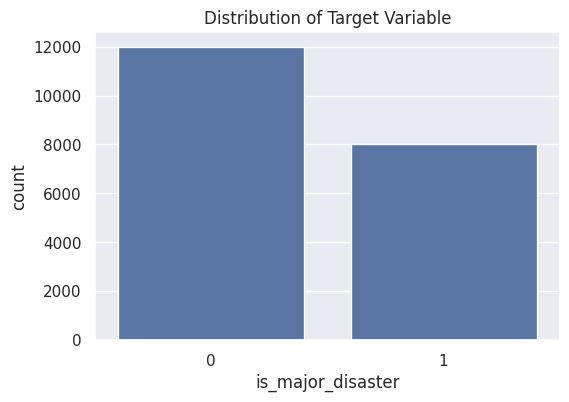

In [ ]:
#EDA
plt.figure(figsize=(6,4))
sns.countplot(x='is_major_disaster', data=df)
plt.title("Distribution of Target Variable")
plt.show()


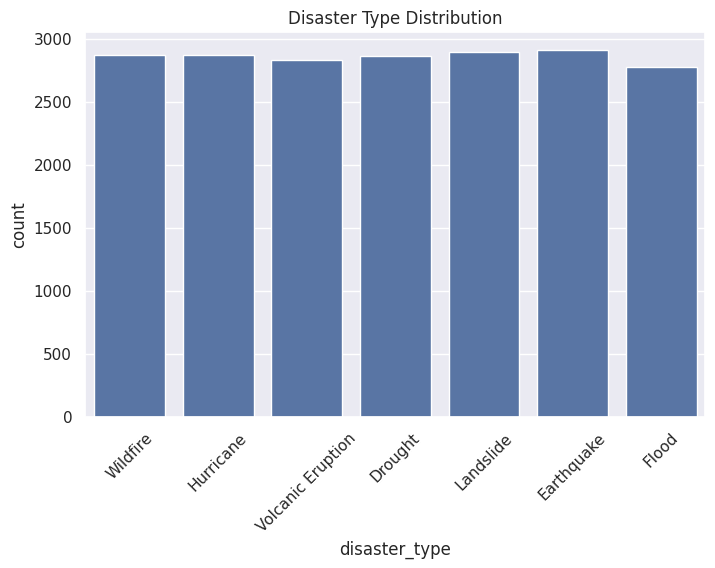

In [ ]:
#histogram
plt.figure(figsize=(8,5))
sns.countplot(x='disaster_type', data=df)
plt.title("Disaster Type Distribution")
plt.xticks(rotation=45)
plt.show()


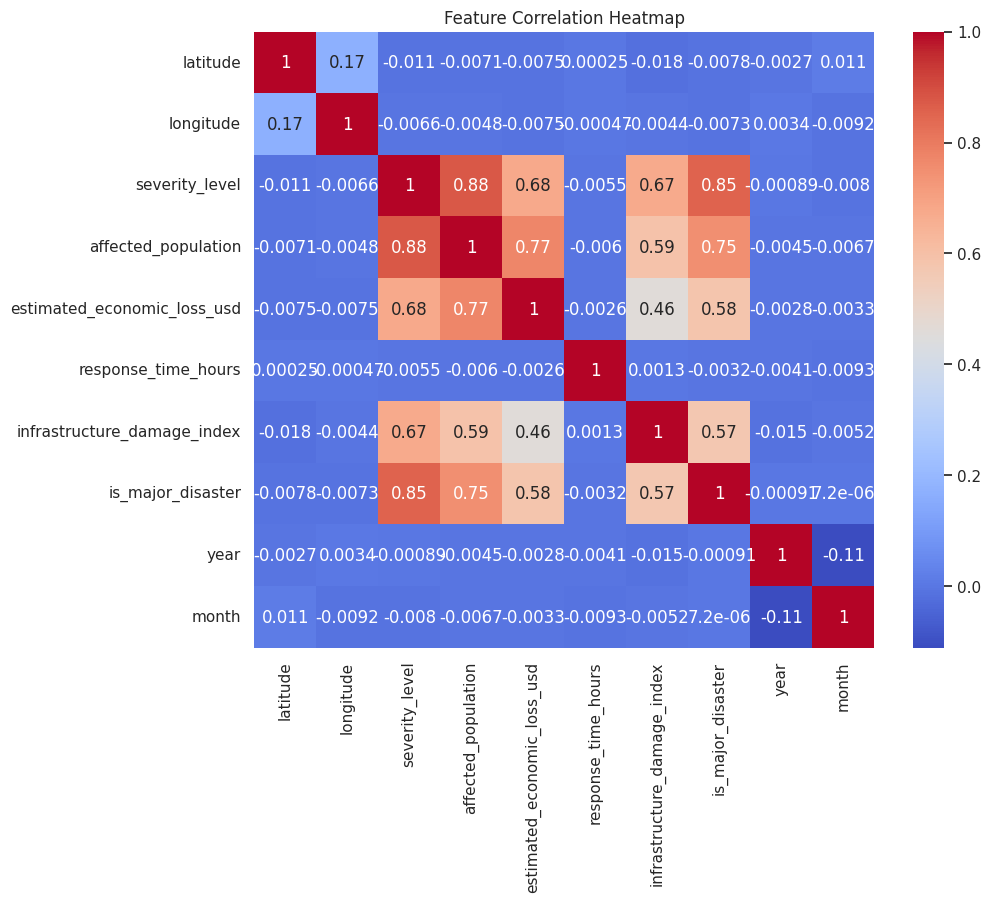

In [ ]:
#heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


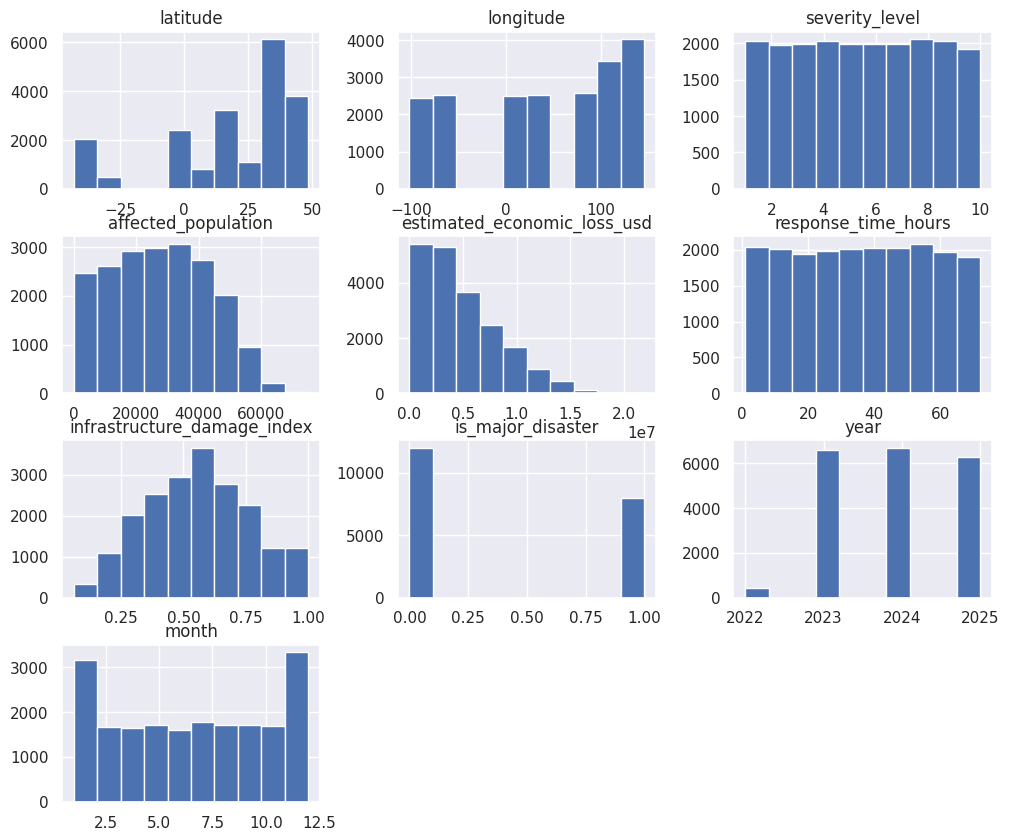

In [ ]:
df.hist(figsize=(12,10))
plt.show()


In [ ]:
#feature engieering
le = LabelEncoder()

df['disaster_type'] = le.fit_transform(df['disaster_type'])
df['location'] = le.fit_transform(df['location'])


In [ ]:
#data preprocessing
df['aid_provided'] = df['aid_provided'].map({'Yes':1, 'No':0})


In [ ]:
#featture selection
X = df.drop('is_major_disaster', axis=1)
y = df['is_major_disaster']


In [ ]:
#train n test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (16000, 12)
Testing samples: (4000, 12)


In [ ]:
#feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)


In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)


In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


In [ ]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)


In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)


In [ ]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}


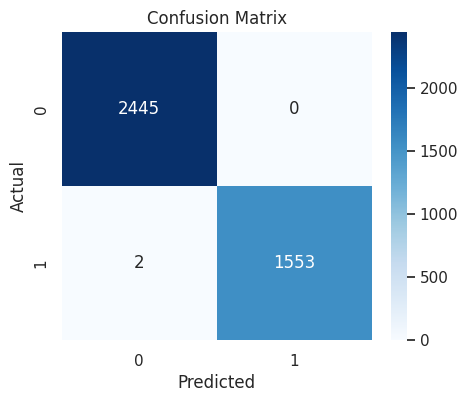

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)

    results.append([name, acc, prec, rec, f1, specificity])


In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Specificity"
])

print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score  Specificity
0  Logistic Regression   0.99925   1.000000  0.998071  0.999034     1.000000
1        Decision Tree   1.00000   1.000000  1.000000  1.000000     1.000000
2        Random Forest   0.99925   1.000000  0.998071  0.999034     1.000000
3                  SVM   0.99925   1.000000  0.998071  0.999034     1.000000
4                  KNN   0.94075   0.919211  0.929260  0.924209     0.948057
5          Naive Bayes   0.95675   0.927070  0.964630  0.945477     0.951738
6    Gradient Boosting   1.00000   1.000000  1.000000  1.000000     1.000000


In [ ]:
#best model
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))


[[2445    0]
 [   3 1552]]


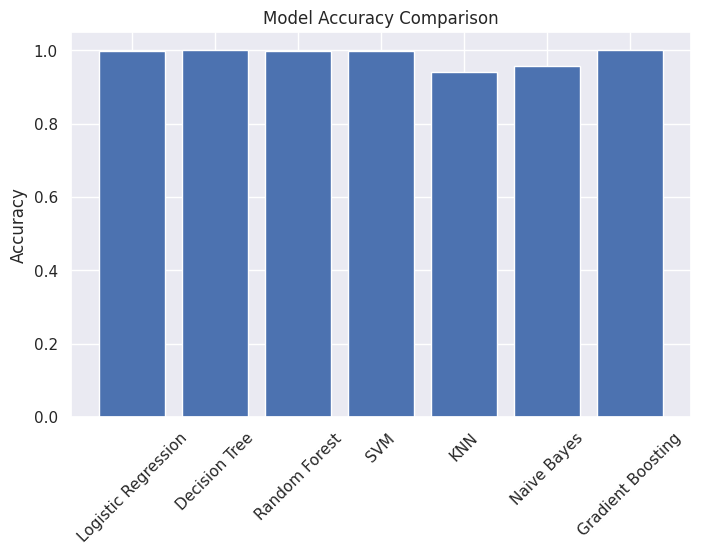

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]


In [ ]:
#errror analysis
rmse = np.sqrt(mean_squared_error(y_test, y_prob))
print("RMSE:", rmse)


RMSE: 0.023326487090858758


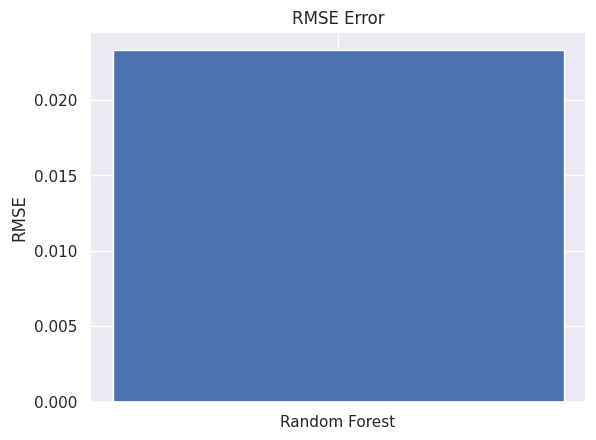

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["Random Forest"], [rmse])
plt.title("RMSE Error")
plt.ylabel("RMSE")
plt.show()


In [ ]:
#hyperparametr for Random forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
#HYPER FOR LR
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=1000)

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(lr, param_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best LR:", grid_lr.best_params_)

In [ ]:
#SVM
from sklearn.svm import SVC

svm = SVC(probability=True)

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(svm, param_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best SVM:", grid_svm.best_params_)

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(knn, param_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

print("Best KNN:", grid_knn.best_params_)

In [ ]:
#NAIVE
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

param_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

grid_nb = GridSearchCV(nb, param_nb, cv=5, scoring='accuracy')
grid_nb.fit(X_train, y_train)

print("Best NB:", grid_nb.best_params_)

In [ ]:
#GB
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

param_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, param_gb, cv=5, scoring='accuracy')
grid_gb.fit(X_train, y_train)

print("Best GB:", grid_gb.best_params_)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5)
grid_rf.fit(X_train, y_train)
best_model = grid_rf.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

print("Cross Validation Results:\n")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.4f}")

Cross Validation Results:

Logistic Regression: 0.9997
Random Forest: 0.9998
SVM: 0.7613
KNN: 0.8522
Naive Bayes: 0.8596
Gradient Boosting: 1.0000


In [ ]:
#overfitting
print("\nOverfitting Analysis:\n")

for name, model in models.items():
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print("-"*30)


Overfitting Analysis:

Logistic Regression
Train Accuracy: 0.9998
Test Accuracy : 0.9992
------------------------------
Decision Tree
Train Accuracy: 1.0000
Test Accuracy : 1.0000
------------------------------
Random Forest
Train Accuracy: 1.0000
Test Accuracy : 0.9992
------------------------------
SVM
Train Accuracy: 0.9998
Test Accuracy : 0.9992
------------------------------
KNN
Train Accuracy: 0.9622
Test Accuracy : 0.9407
------------------------------
Naive Bayes
Train Accuracy: 0.9514
Test Accuracy : 0.9567
------------------------------
Gradient Boosting
Train Accuracy: 1.0000
Test Accuracy : 1.0000
------------------------------


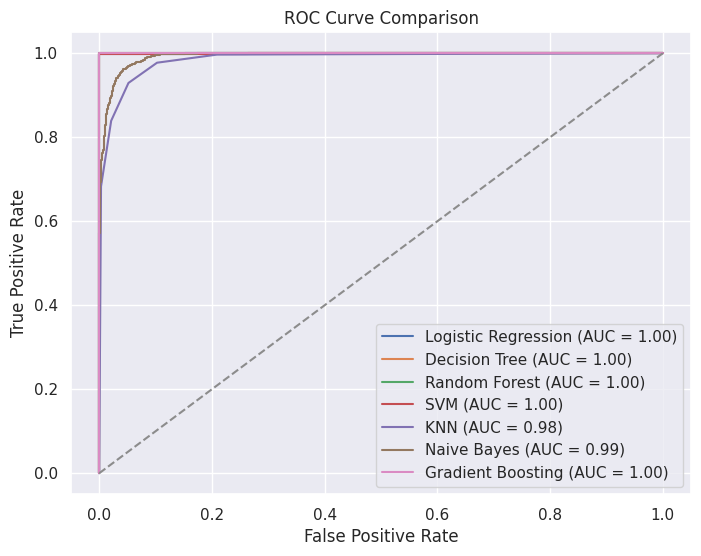

In [ ]:
#Roc CURVE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)

    # For models that support probability
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()